# Testing Libraries

In [1]:
%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=1
!export BART_CPU_ONLY=1
!export CUDA_LAUNCH_BLOCKING=1

import importlib
import sys
import os

os.environ['BART_TOOLBOX_PATH'] = '/home/rinbha/Packages/bart-0.9.00'
os.environ['BART_CPU_ONLY'] = '1'
sys.path.append(os.path.join(os.environ['BART_TOOLBOX_PATH'], 'python'))
sys.path.insert(0, "/home/rinbha/Research/BPT_MOTUS/nonrigid-motion-bpt")
import sigpy as sp
import sigpy.plot as pl

import matplotlib.pyplot as plt
import numpy as np

# plotting
%matplotlib widget
plt.rcParams.update({
    'axes.spines.top': False,           # Remove top spine
    'axes.spines.right': False,         # Remove right spine
    'axes.titlesize': 20,               # Increase title font size
    'axes.labelsize': 18,               # Increase axis label font size
    'xtick.labelsize': 16,              # Increase x-tick label size
    'ytick.labelsize': 16,              # Increase y-tick label size
    "text.usetex": False,                # Enable LaTeX 
    'legend.fontsize': 12,
    'font.family': 'Avenir' # Avenir font
})

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=1


In [2]:
from bpt_motus.io import bSSFPArchive
from bpt_motus.preprocessing import SplitXkBPT

In [3]:
# Path to bSSFP ScanArchive folder
inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/lung_ute/air_bpt_sweeps_030926/Series9_antcenter_rocker"

# Create the object
bssfp = bSSFPArchive(inpdir)

# Process ScanArchives and save metadata, time-ordered k-space, and trajectory-ordered k-space into inpdir. 
# This is a one-time step, and the saved files can be loaded in future runs without needing to reprocess the ScanArchives.
bssfp.get_metadata(force_reload=False) # store metadata in .pkl
bssfp.get_ksp(force_reload=False) # store time-ordered and trajectory-ordered k-space in .npy files

INFO: Loading cached metadata from /mikLKS/rinbha/BPT/MRMOTUS/lung_ute/air_bpt_sweeps_030926/Series9_antcenter_rocker/metadata_dict.pkl
INFO: Loading cached k-space from /mikLKS/rinbha/BPT/MRMOTUS/lung_ute/air_bpt_sweeps_030926/Series9_antcenter_rocker


In [37]:
print(f"xk_time shape: {bssfp.xk_time.shape}")
print(f"xk_recon shape: {bssfp.xk_recon.shape}")

xk_time shape: (16, 38400, 256)
xk_recon shape: (256, 150, 256, 16)


In [4]:
# Split the data into cleaned, coil-compressed, time-ordered k-space data (without BPT) 
# and BPT signals
split_xk_bpt = SplitXkBPT(inp_dir=inpdir, verbose=True)
split_xk_bpt.num_bpts = 1 # set this to the # of BPT/PTs transmitting
split_xk_bpt.xk_raw_fname = "xk_time.npy" # this is the file name of the time-ordered k-space (don't change this if you used bssfp_reader)

# Store the cleaned, coil-compressed, time-ordered k-space data (without BPT) and BPT signals into .npy files in inpdir.
# This is a one-time step, and the saved files can be loaded in future runs without needing to reprocess the ScanArchives.
split_xk_bpt.run(force_reload=False)

INFO: Cleaned k-space and raw BPT/PT signals found. Opening...


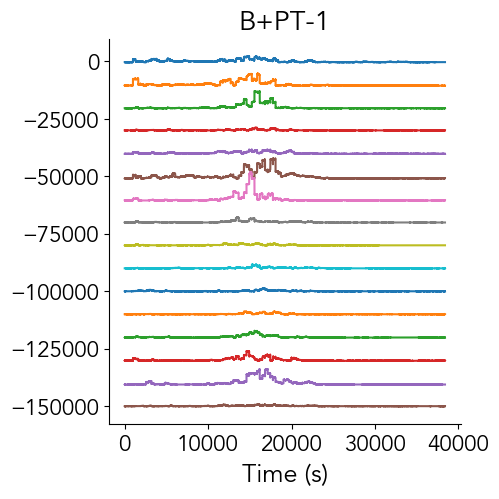

In [8]:
%matplotlib inline 

def plot_bpts(bpt, tr=1, shift=0, subplot_size=5, titles=None, ncols=2):
    nbpts, npe, ncoils = bpt.shape

    if titles is None:
        titles = [f"B+PT-{i+1}" for i in range(nbpts)]

    nrows = int(np.ceil(nbpts / ncols))
    figsize = (ncols * subplot_size, nrows * subplot_size)
    t = np.arange(npe) * tr

    plt.figure(figsize=figsize)
    for i in range(nbpts):
        plt.subplot(nrows, ncols, i + 1)
        plt.plot(t, bpt[i] - np.mean(bpt[i], axis=0) + np.arange(ncoils) * shift)
        plt.title(titles[i])
        if i >= (nrows - 1) * ncols:  # last row
            plt.xlabel("Time (s)")

plot_bpts(split_xk_bpt.bpts, shift=-1e4)